<a href="https://colab.research.google.com/github/Rutwij12/nlp-cw/blob/main/NLP_CW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loader

In [1]:
import pandas as pd
import ast

def process_pcl_data(full_data_path, train_data_path, output_path):
    """
    Merges the PCL TSV and CSV files, transforms the labels into a binary target,
    and saves the result.
    """
    print(f"Starting processing: {full_data_path} + {train_data_path}")

    # 1. Load the TSV file (The 'Full' dataset)
    # Based on the Don't Patronize Me! dataset structure
    columns_full = ['par_id', 'semeval_id', 'keyword', 'country_code', 'text', 'original_label']
    df_full = pd.read_csv(full_data_path, sep='\t', header=None, names=columns_full, skiprows=4)

    # 2. Load the CSV file (The 'Labels' dataset)
    df_labels = pd.read_csv(train_data_path)

    # 3. Data Cleaning: Ensure par_id is the same type in both (Integer)
    # This prevents merge failures if one is read as a string and the other as an int
    df_full['par_id'] = pd.to_numeric(df_full['par_id'], errors='coerce')
    df_labels['par_id'] = pd.to_numeric(df_labels['par_id'], errors='coerce')

    # 4. Merge the datasets
    # Using 'inner' or 'right' ensures we only keep rows we actually have labels for
    df_merged = pd.merge(df_full, df_labels, on='par_id', how='right')

    # 5. Define logic for the binary label
    def check_for_pcl(label_str):
        if pd.isna(label_str):
            return 0
        try:
            # Safely evaluate the string representation of a list (e.g., "[0, 1, 0]")
            categories = ast.literal_eval(str(label_str))
            # Return 1 if there is at least one '1' in the list (positive for PCL)
            return 1 if 1 in categories else 0
        except (ValueError, SyntaxError):
            # Fallback if the label isn't a list-string
            return 0

    # 6. Apply transformation
    df_merged['final_label'] = df_merged['label'].apply(check_for_pcl)

    # 7. Clean up columns
    # We remove 'original_label' and the raw 'label' list to keep things tidy
    cols_to_drop = [c for c in ['original_label', 'label'] if c in df_merged.columns]
    df_merged = df_merged.drop(columns=cols_to_drop)

    # 8. Save the data
    df_merged.to_csv(output_path, index=False)

    print(f"Success! Saved {len(df_merged)} rows to {output_path}")
    print(df_merged[['par_id', 'keyword', 'final_label']].head())

    return df_merged

if __name__ == "__main__":
    df1 = process_pcl_data(
        full_data_path='original_data/full_data.tsv',
        train_data_path='original_data/train_data_raw.csv',
        output_path='train_data.csv'
    )

    df2 = process_pcl_data(
        full_data_path='original_data/full_data.tsv',
        train_data_path='original_data/test_data_raw.csv',
        output_path='test_data.csv'
    )

    df = pd.concat([df1, df2], ignore_index=True)

    df.to_csv('all_data.csv', index=False)

Starting processing: original_data/full_data.tsv + original_data/train_data_raw.csv
Success! Saved 8375 rows to train_data.csv
   par_id        keyword  final_label
0    4341  poor-families            1
1    4136       homeless            1
2   10352  poor-families            1
3    8279     vulnerable            1
4    1164  poor-families            1
Starting processing: original_data/full_data.tsv + original_data/test_data_raw.csv
Success! Saved 2094 rows to test_data.csv
   par_id   keyword  final_label
0    4046  hopeless            1
1    1279   refugee            1
2    8330   refugee            1
3    4063   in-need            1
4    4089  homeless            1



===== DUPLICATE DETECTION =====

Exact Text Duplicates: 0 rows
  Unique duplicate texts: 0

Checking for duplicates with conflicting labels:

===== SPECIAL CHARACTERS & HTML DETECTION =====

HTML/Special Character Patterns Found:
  amp: 61 rows (0.58%)
  lt: 0 rows (0.00%)
  gt: 17 rows (0.16%)
  quot: 0 rows (0.00%)
  apos: 0 rows (0.00%)
  html_tags: 401 rows (3.83%)
  newlines: 0 rows (0.00%)
  tabs: 0 rows (0.00%)
  unicode_escapes: 0 rows (0.00%)

Punctuation Statistics:
  Mean punctuation density: 0.0239
  Max punctuation density: 0.2000
  Rows with >50% punctuation: 0

Non-ASCII Characters:
  Rows with non-ASCII: 0 (0.00%)

===== OUTLIER DETECTION =====

Token Count Statistics:
  Mean: 43.19
  Median: 37.00
  Std Dev: 26.01
  Min: 0
  Max: 819
  Q1 (25%): 27.00
  Q3 (75%): 53.00

Outliers (IQR method):
  Lower bound: -12.00 tokens
  Upper bound: 92.00 tokens
  Total outliers: 490 rows (4.68%)

Very Short Texts (<5 tokens): 23 rows (0.22%)
  Examples:
    'The Filipino immigrant

/tmp/ipykernel_1458/471212473.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No PCL (0)', 'PCL (1)'])


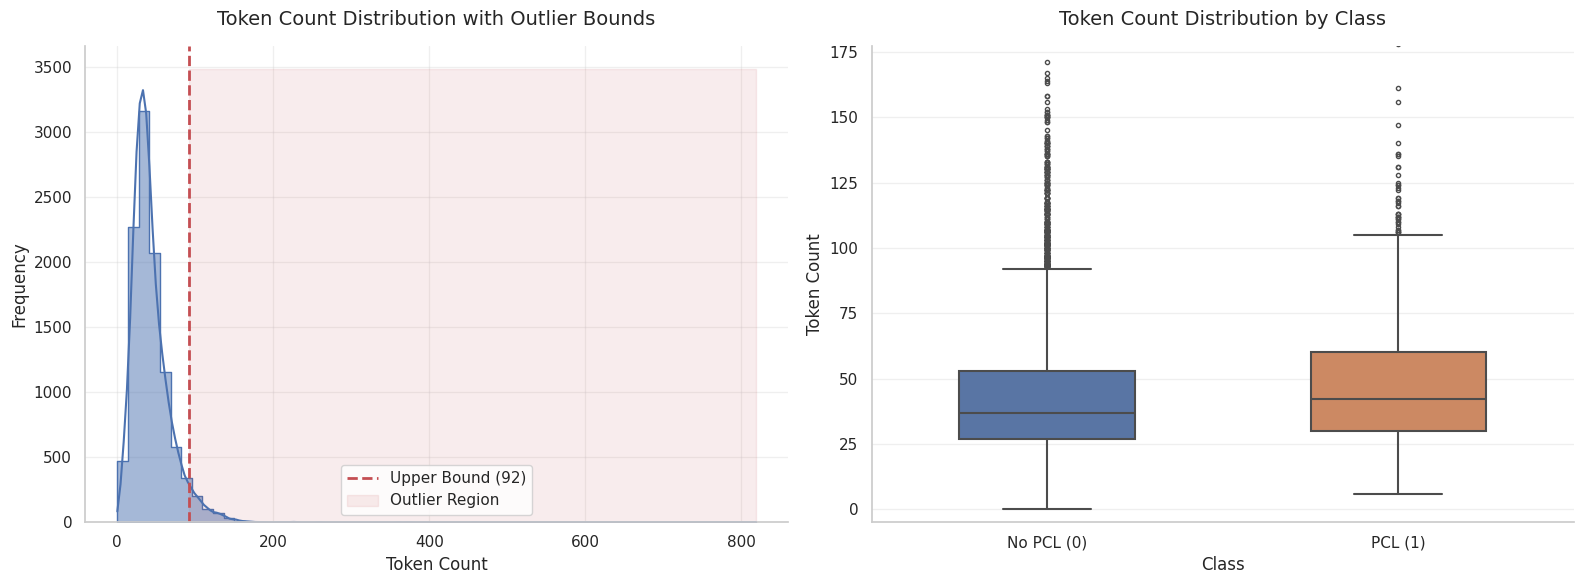


===== NOISE SUMMARY REPORT =====

Total Records: 10469

1. DUPLICATES:
   - Exact duplicates: 0

2. SPECIAL CHARACTERS/HTML:
   - Non-ASCII rows: 0
   - High punctuation (>50%): 0

3. OUTLIERS:
   - Length outliers: 490
   - Very short (<5 tokens): 23
   - Very long (>200 tokens): 9

Outliers saved to: EDA/LexicalAnalysis/outliers_detected.csv


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from pathlib import Path

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3

# Define the folder name/path
folder_path = Path("EDA/LexicalAnalysis")

# Create the folder
folder_path.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv('all_data.csv')
# Ensure integer type for labels (helps with categorical plotting later)
df['y'] = (df['final_label'] == 1).astype(int)

# DUPLICATES

print("\n===== DUPLICATE DETECTION =====")

# Check for exact text duplicates
exact_duplicates = df[df.duplicated(subset=['text'], keep=False)]
num_exact_duplicates = len(exact_duplicates)
print(f"\nExact Text Duplicates: {num_exact_duplicates} rows")
print(f"  Unique duplicate texts: {df['text'].duplicated().sum()}")

if num_exact_duplicates > 0:
    print("\nSample duplicate texts:")
    dup_texts = df['text'].value_counts()
    dup_texts = dup_texts[dup_texts > 1]
    for text, count in dup_texts.head(5).items():
        print(f"  '{text[:80]}...' appears {count} times")

# Check for near-duplicates (same text with different labels)
print("\nChecking for duplicates with conflicting labels:")
for text, group in df.groupby('text'):
    if len(group['y'].unique()) > 1:
        print(f"  Conflicting labels for: '{text[:80]}...'")
        print(f"    Labels: {group['y'].unique()}")
        break

# SPECIAL CHARACTERS & HTML

print("\n===== SPECIAL CHARACTERS & HTML DETECTION =====")

# Common HTML entities and special patterns
html_patterns = {
    'amp': r'&amp;',
    'lt': r'&lt;',
    'gt': r'&gt;',
    'quot': r'&quot;',
    'apos': r'&apos;',
    'html_tags': r'<[^>]+>',
    'newlines': r'\\n|\n',
    'tabs': r'\\t|\t',
    'unicode_escapes': r'\\u[0-9a-fA-F]{4}',
}

print("\nHTML/Special Character Patterns Found:")
for pattern_name, pattern in html_patterns.items():
    count = df['text'].str.contains(pattern, regex=True, na=False).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pattern_name}: {count} rows ({percentage:.2f}%)")

    if count > 0 and count <= 5:
        print(f"    Examples:")
        examples = df[df['text'].str.contains(pattern, regex=True, na=False)]['text'].head(3)
        for ex in examples:
            print(f"      '{ex[:80]}...'")

# Check for excessive punctuation
def count_punctuation(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'[!?.,;:\-\(\)\[\]{}\"\'\/\\@#$%^&*+=]', text))

df['punctuation_count'] = df['text'].apply(count_punctuation)
df['punctuation_density'] = df['punctuation_count'] / df['text'].str.len()

print(f"\nPunctuation Statistics:")
print(f"  Mean punctuation density: {df['punctuation_density'].mean():.4f}")
print(f"  Max punctuation density: {df['punctuation_density'].max():.4f}")
print(f"  Rows with >50% punctuation: {(df['punctuation_density'] > 0.5).sum()}")

# Check for non-ASCII characters
def has_non_ascii(text):
    if not isinstance(text, str):
        return False
    return any(ord(char) > 127 for char in text)

non_ascii_count = df['text'].apply(has_non_ascii).sum()
print(f"\nNon-ASCII Characters:")
print(f"  Rows with non-ASCII: {non_ascii_count} ({(non_ascii_count/len(df)*100):.2f}%)")

######## OUTLIERS #######

print("\n===== OUTLIER DETECTION =====")

# Text length analysis
df['text_length'] = df['text'].str.len()

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['token_count'] = df['tokens'].apply(len)

print(f"\nToken Count Statistics:")
print(f"  Mean: {df['token_count'].mean():.2f}")
print(f"  Median: {df['token_count'].median():.2f}")
print(f"  Std Dev: {df['token_count'].std():.2f}")
print(f"  Min: {df['token_count'].min()}")
print(f"  Max: {df['token_count'].max()}")
print(f"  Q1 (25%): {df['token_count'].quantile(0.25):.2f}")
print(f"  Q3 (75%): {df['token_count'].quantile(0.75):.2f}")

# IQR-based outlier detection
Q1 = df['token_count'].quantile(0.25)
Q3 = df['token_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['token_count'] < lower_bound) | (df['token_count'] > upper_bound)]
print(f"\nOutliers (IQR method):")
print(f"  Lower bound: {lower_bound:.2f} tokens")
print(f"  Upper bound: {upper_bound:.2f} tokens")
print(f"  Total outliers: {len(outliers)} rows ({(len(outliers)/len(df)*100):.2f}%)")

# Short texts (< 5 tokens)
short_texts = df[df['token_count'] < 5]
print(f"\nVery Short Texts (<5 tokens): {len(short_texts)} rows ({(len(short_texts)/len(df)*100):.2f}%)")
if len(short_texts) > 0:
    print(f"  Examples:")
    for text in short_texts['text'].head(5):
        print(f"    '{text}'")

# Long texts (> 200 tokens)
long_texts = df[df['token_count'] > 200]
print(f"\nVery Long Texts (>200 tokens): {len(long_texts)} rows ({(len(long_texts)/len(df)*100):.2f}%)")
if len(long_texts) > 0:
    print(f"  Sample long text length: {long_texts['token_count'].iloc[0]} tokens")

# Class-wise outlier analysis
print(f"\nOutlier Distribution by Class:")
print(f"  Class 0 (No PCL) outliers: {len(outliers[outliers['y']==0])} / {(outliers['y']==0).sum()}")
print(f"  Class 1 (PCL) outliers: {len(outliers[outliers['y']==1])} / {(outliers['y']==1).sum()}")

# --- IMPROVED VISUALIZATIONS ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram with Outlier bounds highlighted

sns.histplot(data=df, x='token_count', bins=60, kde=True, ax=axes[0],
             color="#4C72B0", alpha=0.5, element="step")

# Highlight lower bound (if applicable/above 0) and upper bound
if lower_bound > 0:
    axes[0].axvline(lower_bound, color='#C44E52', linestyle='--', linewidth=2, label=f'Lower Bound ({lower_bound:.0f})')
axes[0].axvline(upper_bound, color='#C44E52', linestyle='--', linewidth=2, label=f'Upper Bound ({upper_bound:.0f})')

# Shade the upper outlier region
y_min, y_max = axes[0].get_ylim()
axes[0].fill_betweenx([y_min, y_max], upper_bound, df['token_count'].max(),
                      color='#C44E52', alpha=0.1, label='Outlier Region')

axes[0].set_xlabel('Token Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Token Count Distribution with Outlier Bounds', fontsize=14, pad=15)
axes[0].legend()

# 2. Box plot by class

sns.boxplot(data=df, x='y', y='token_count', hue='y', ax=axes[1],
            palette={0: "#4C72B0", 1: "#DD8452"},
            width=0.5, fliersize=3, linewidth=1.5, legend=False)

axes[1].set_ylabel('Token Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_xticklabels(['No PCL (0)', 'PCL (1)'])
axes[1].set_title('Token Count Distribution by Class', fontsize=14, pad=15)

# Optional: Focus the y-axis to see the IQR boxes clearly if extreme outliers squash them
axes[1].set_ylim(-5, df['token_count'].quantile(0.99) + 50)

plt.tight_layout()
plt.savefig(f'{folder_path}/outlier_detection_styled.png', bbox_inches='tight')
plt.show()

######## SUMMARY REPORT #######

print("\n===== NOISE SUMMARY REPORT =====")
print(f"\nTotal Records: {len(df)}")
print(f"\n1. DUPLICATES:")
print(f"   - Exact duplicates: {df['text'].duplicated().sum()}")
print(f"\n2. SPECIAL CHARACTERS/HTML:")
print(f"   - Non-ASCII rows: {non_ascii_count}")
print(f"   - High punctuation (>50%): {(df['punctuation_density'] > 0.5).sum()}")
print(f"\n3. OUTLIERS:")
print(f"   - Length outliers: {len(outliers)}")
print(f"   - Very short (<5 tokens): {len(short_texts)}")
print(f"   - Very long (>200 tokens): {len(long_texts)}")

# Save outlier info to CSV for further inspection
if len(outliers) > 0:
    outliers_to_inspect = outliers[['text', 'token_count', 'final_label', 'y']].copy()
    outliers_to_inspect.to_csv(f'{folder_path}/outliers_detected.csv', index=False)
    print(f"\nOutliers saved to: {folder_path}/outliers_detected.csv")

Noise Artifacts


===== N-GRAM ANALYSIS =====

Top 20 Bigrams:
[(('of', 'the'), 2711), (('in', 'the'), 2460), (('to', 'the'), 1315), (('in', 'need'), 1025), (('poor', 'families'), 921), (('for', 'the'), 873), (('on', 'the'), 811), (('to', 'be'), 740), (('and', 'the'), 734), (('at', 'the'), 653), (('need', 'of'), 605), (('in', 'a'), 587), (('by', 'the'), 563), (('that', 'the'), 549), (('of', 'a'), 541), (('from', 'the'), 535), (('with', 'the'), 502), (('it', 'is'), 497), (('is', 'a'), 448), (('as', 'a'), 443)]

Top 20 Trigrams:
[(('in', 'need', 'of'), 594), (('from', 'poor', 'families'), 230), (('one', 'of', 'the'), 190), (('those', 'in', 'need'), 162), (('as', 'well', 'as'), 153), (('the', 'united', 'states'), 145), (('the', 'number', 'of'), 135), (('the', 'most', 'vulnerable'), 122), (('in', 'the', 'country'), 114), (('are', 'in', 'need'), 111), (('some', 'of', 'the'), 105), (('according', 'to', 'the'), 101), (('the', 'u', 's'), 93), (('need', 'of', 'a'), 88), (('poor', 'families', 'in'), 84), (('poor

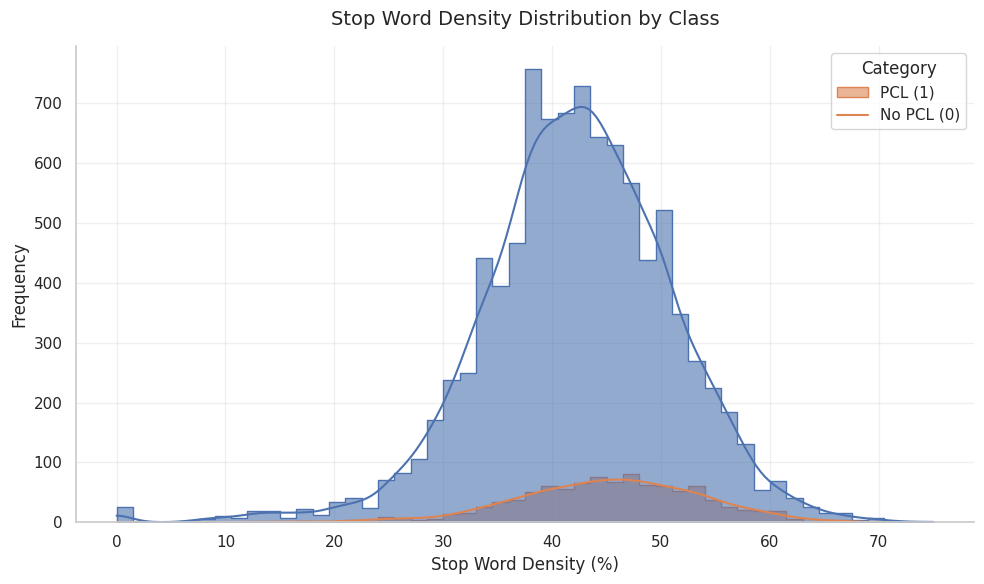


===== WORD CLOUDS & FREQUENCY =====


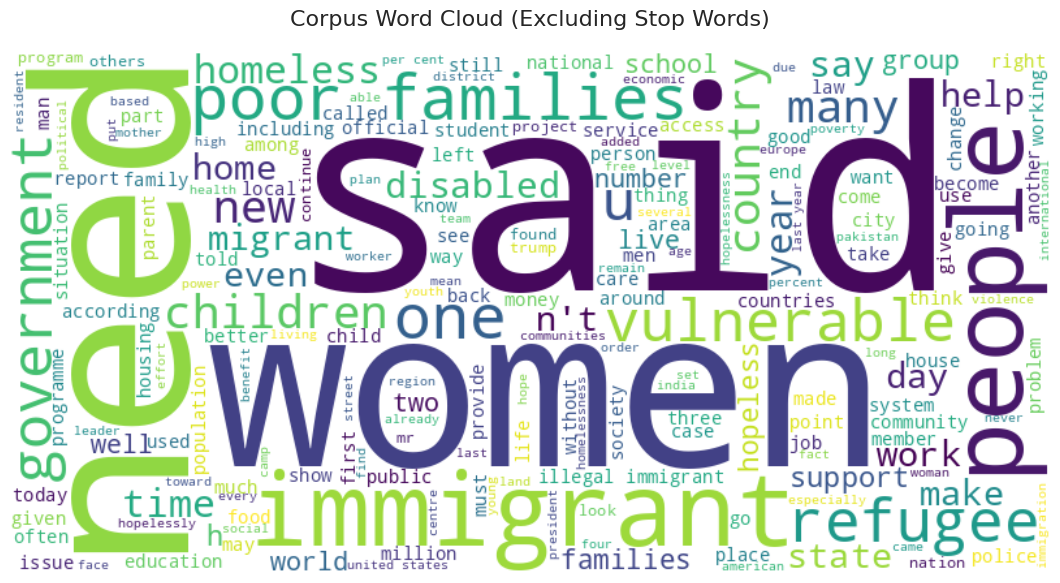

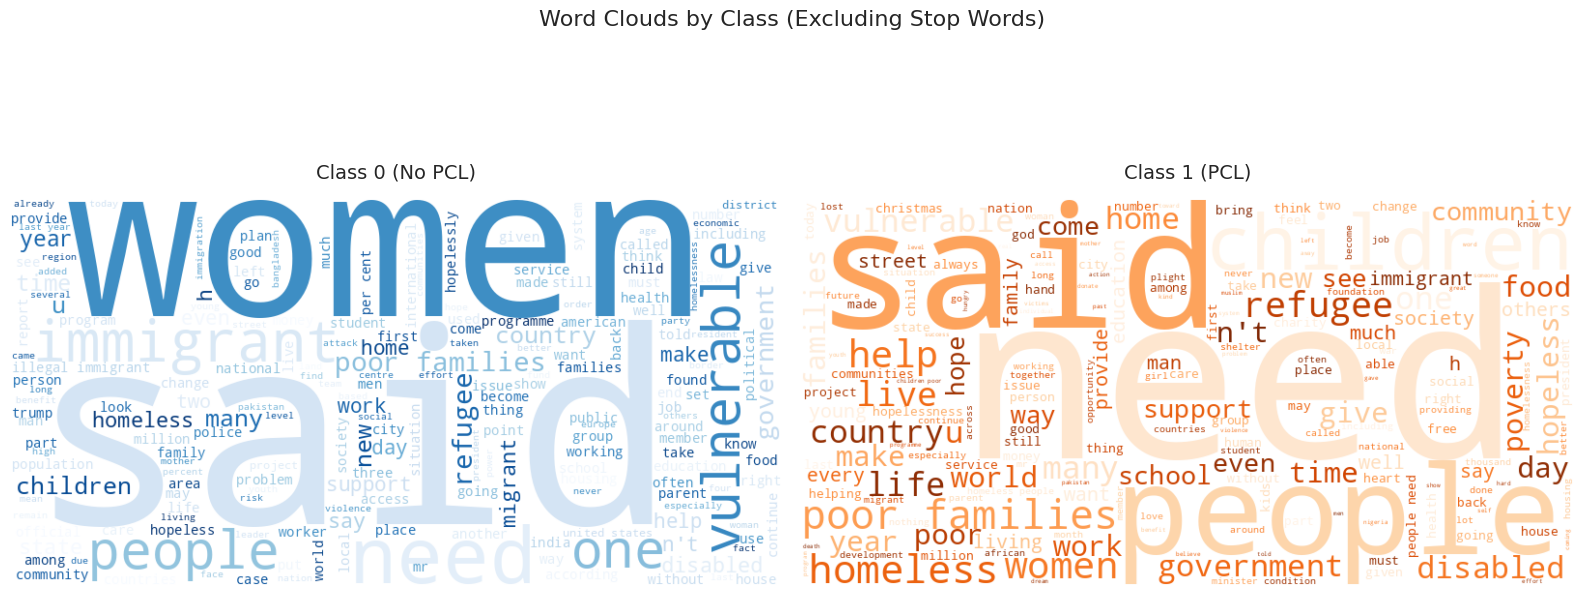

/tmp/ipykernel_1458/629261525.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(tokens_only), palette="mako", ax=ax)


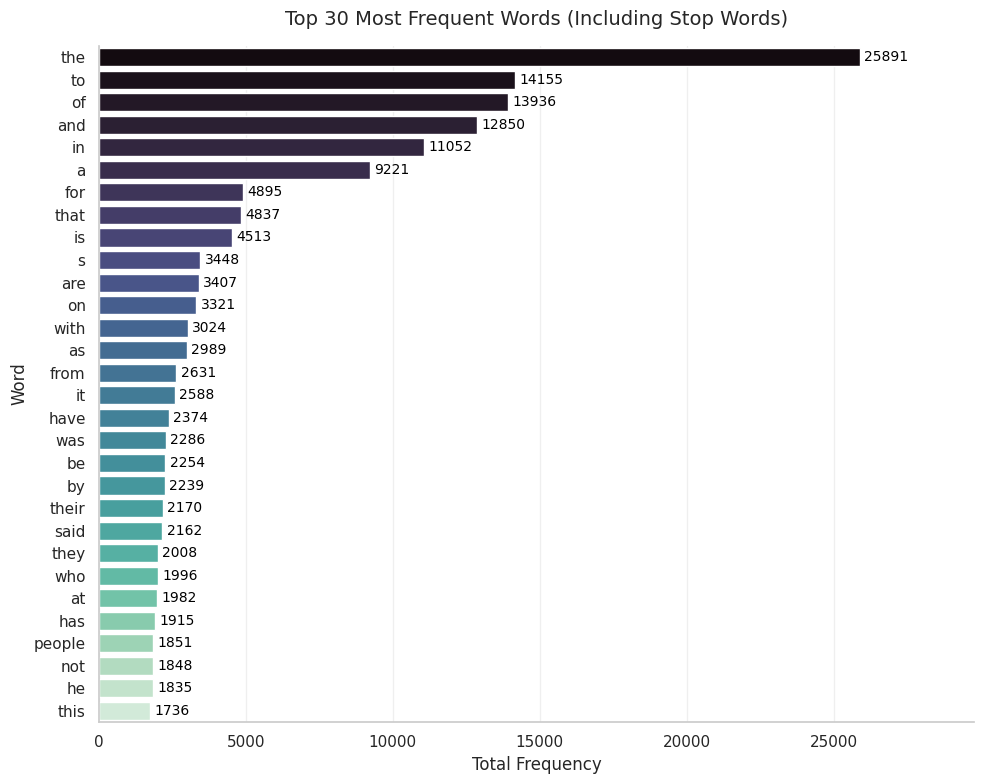


Top 30 Words (including stop words):
[('the', 25891), ('to', 14155), ('of', 13936), ('and', 12850), ('in', 11052), ('a', 9221), ('for', 4895), ('that', 4837), ('is', 4513), ('s', 3448), ('are', 3407), ('on', 3321), ('with', 3024), ('as', 2989), ('from', 2631), ('it', 2588), ('have', 2374), ('was', 2286), ('be', 2254), ('by', 2239), ('their', 2170), ('said', 2162), ('they', 2008), ('who', 1996), ('at', 1982), ('has', 1915), ('people', 1851), ('not', 1848), ('he', 1835), ('this', 1736)]

Top 30 Words (excluding stop words):
[('said', 2162), ('people', 1851), ('women', 1718), ('need', 1344), ('families', 1341), ('immigrants', 1296), ('vulnerable', 1204), ('poor', 1190), ('disabled', 1145), ('children', 1039), ('homeless', 1035), ('also', 985), ('refugees', 966), ('one', 953), ('government', 852), ('would', 818), ('new', 808), ('many', 789), ('country', 751), ('year', 747), ("n't", 687), ('us', 628), ('immigrant', 550), ('help', 540), ('h', 538), ('hopeless', 535), ('two', 524), ('time', 

In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from pathlib import Path

# Download required NLTK resources
nltk.download('stopwords', quiet=True)

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3

# Define the folder name/path
folder_path = Path("EDA/NoiseArtifacts")

# Create the folder
folder_path.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv('all_data.csv')
# Ensure labels are integers for categorical plotting
df['y'] = (df['final_label'] >= 1).astype(int)

# Create a column for tokenized text
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)

# Get English stop words
stop_words = set(stopwords.words('english'))

######## N-GRAM ANALYSIS #######

def get_ngrams(tokens, n):
    """Extract n-grams from token list"""
    return list(ngrams(tokens, n))

# Get all bigrams and trigrams
all_tokens = [token for tokens in df['tokens'] for token in tokens]
all_bigrams = [bigram for tokens in df['tokens'] for bigram in get_ngrams(tokens, 2)]
all_trigrams = [trigram for tokens in df['tokens'] for trigram in get_ngrams(tokens, 3)]

bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

print("\n===== N-GRAM ANALYSIS =====")
print("\nTop 20 Bigrams:")
print(bigram_counts.most_common(20))

print("\nTop 20 Trigrams:")
print(trigram_counts.most_common(20))

# By class
print("\n--- Bigrams by Class ---")
class_0_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 0
                    for bigram in get_ngrams(tokens, 2)]
class_1_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 1
                    for bigram in get_ngrams(tokens, 2)]

class_0_bigram_counts = Counter(class_0_bigrams)
class_1_bigram_counts = Counter(class_1_bigrams)

print("\nTop 15 Bigrams (Class 0 - No PCL):")
print(class_0_bigram_counts.most_common(15))

print("\nTop 15 Bigrams (Class 1 - PCL):")
print(class_1_bigram_counts.most_common(15))

######## STOP WORD DENSITY #######

print("\n===== STOP WORD DENSITY =====")

def calculate_stop_word_density(tokens):
    """Calculate percentage of stop words in token list"""
    if len(tokens) == 0:
        return 0
    stop_word_count = sum(1 for token in tokens if token in stop_words)
    return (stop_word_count / len(tokens)) * 100

df['stop_word_density'] = df['tokens'].apply(calculate_stop_word_density)

print(f"\nOverall Stop Word Density:")
print(f"  Mean: {df['stop_word_density'].mean():.2f}%")
print(f"  Median: {df['stop_word_density'].median():.2f}%")
print(f"  Min: {df['stop_word_density'].min():.2f}%")
print(f"  Max: {df['stop_word_density'].max():.2f}%")

print(f"\nStop Word Density by Class:")
print(f"  Class 0 (No PCL) - Mean: {df[df['y']==0]['stop_word_density'].mean():.2f}%")
print(f"  Class 1 (PCL) - Mean: {df[df['y']==1]['stop_word_density'].mean():.2f}%")

# Visualize stop word density distribution

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='stop_word_density', hue='y', bins=50, kde=True,
             palette={0: "#4C72B0", 1: "#DD8452"}, alpha=0.6, element="step")

plt.xlabel('Stop Word Density (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Stop Word Density Distribution by Class', fontsize=14, pad=15)
plt.legend(title="Category", labels=["PCL (1)", "No PCL (0)"])

plt.tight_layout()
plt.savefig(f'{folder_path}/stop_word_density_styled.png')
plt.show()

######## WORD CLOUDS & FREQUENCY #######

print("\n===== WORD CLOUDS & FREQUENCY =====")

# Overall word cloud

all_text = ' '.join([token for tokens in df['tokens'] for token in tokens if token not in stop_words])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Corpus Word Cloud (Excluding Stop Words)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'{folder_path}/wordcloud_all_styled.png')
plt.show()

# Word cloud by class
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Class 0
class_0_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 0
                          for token in tokens if token not in stop_words])
wordcloud_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(class_0_text)
axes[0].imshow(wordcloud_0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Class 0 (No PCL)', fontsize=14, pad=15)

# Class 1
class_1_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 1
                          for token in tokens if token not in stop_words])
wordcloud_1 = WordCloud(width=800, height=400, background_color='white', colormap='Oranges').generate(class_1_text)
axes[1].imshow(wordcloud_1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Class 1 (PCL)', fontsize=14, pad=15)

plt.suptitle('Word Clouds by Class (Excluding Stop Words)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f'{folder_path}/wordcloud_by_class_styled.png', bbox_inches='tight')
plt.show()

# Word frequency (top 30)

fig, ax = plt.subplots(figsize=(10, 8))
top_30_tokens = Counter(all_tokens).most_common(30)
tokens_only, freqs = zip(*top_30_tokens)

# Modern Seaborn Horizontal Barplot
sns.barplot(x=list(freqs), y=list(tokens_only), palette="mako", ax=ax)

ax.set_xlabel('Total Frequency', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title('Top 30 Most Frequent Words (Including Stop Words)', fontsize=14, pad=15)

# Add numeric labels to the end of each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 150, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10, color='black')

# Expand x-axis slightly to make room for the text annotations
ax.set_xlim(0, max(freqs) * 1.15)

plt.tight_layout()
plt.savefig(f'{folder_path}/top_30_words_styled.png')
plt.show()

print("\nTop 30 Words (including stop words):")
print(Counter(all_tokens).most_common(30))

print("\nTop 30 Words (excluding stop words):")
non_stop_tokens = [token for token in all_tokens if token not in stop_words]
print(Counter(non_stop_tokens).most_common(30))

Statistical Profiling

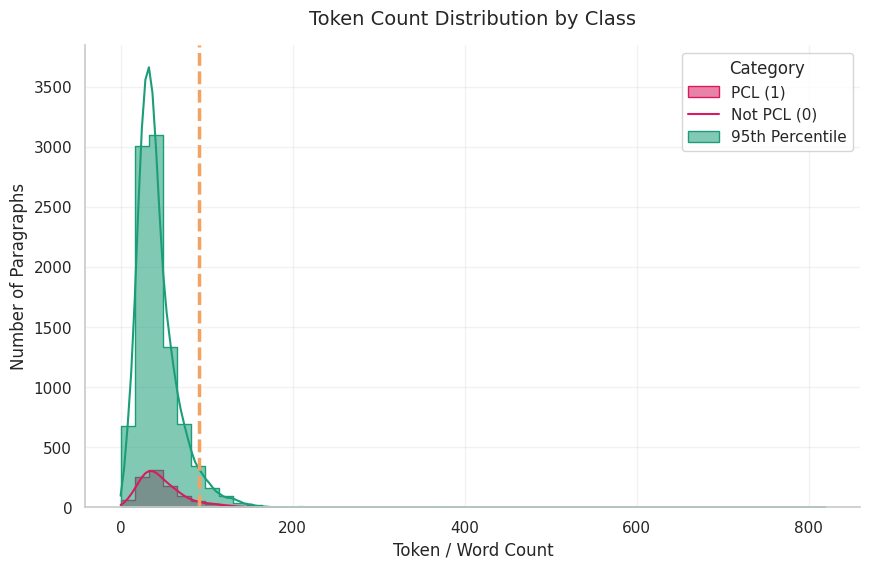

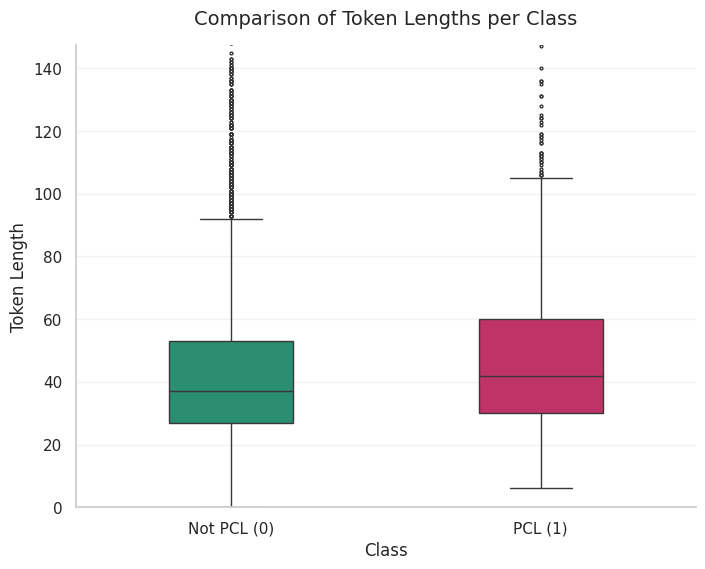

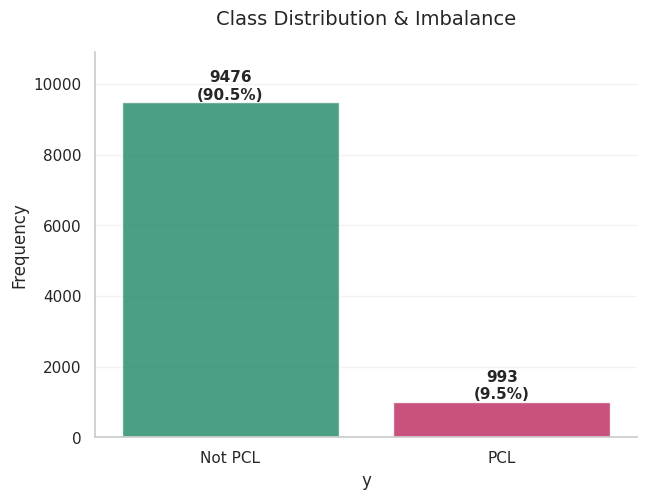


Vocabulary Size: 29091
Total Tokens: 452194

Top 20 Words: [('the', 25891), ('to', 14155), ('of', 13936), ('and', 12850), ('in', 11052), ('a', 9221), ('for', 4895), ('that', 4837), ('is', 4513), ('s', 3448), ('are', 3407), ('on', 3321), ('with', 3024), ('as', 2989), ('from', 2631), ('it', 2588), ('have', 2374), ('was', 2286), ('be', 2254), ('by', 2239)]


In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.25

# New Color Palette (More Distinct & Modern)
COLOR_NOT_PCL = "#1B9E77"   # Deep Teal
COLOR_PCL     = "#D81B60"   # Vibrant Magenta
COLOR_ACCENT  = "#F4A261"   # Warm Gold Accent

palette = {0: COLOR_NOT_PCL, 1: COLOR_PCL}

path = "EDA/Statistical_Profiling_Diagrams"
folder_path = Path(path)
folder_path.mkdir(parents=True, exist_ok=True)

# --- DATA PREPARATION ---
df = pd.read_csv('all_data.csv')
df['y'] = df['final_label'].astype(int)

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")
def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['length'] = df['tokens'].apply(len)

token_stats = {
    "mean_length": df["length"].mean(),
    "median_length": df["length"].median(),
    "p95_length": df["length"].quantile(0.95)
}

# --- VISUALIZATION 1: TOKEN COUNT DISTRIBUTION ---

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="length",
    hue="y",
    bins=50,
    kde=True,
    palette=palette,
    alpha=0.55,
    element="step"
)

p95 = token_stats["p95_length"]
plt.axvline(
    p95,
    color=COLOR_ACCENT,
    linestyle='--',
    linewidth=2.5,
    label=f'95th Percentile ({p95:.0f} tokens)'
)

plt.xlabel("Token / Word Count")
plt.ylabel("Number of Paragraphs")
plt.title("Token Count Distribution by Class", fontsize=14, pad=15)

plt.legend(
    title="Category",
    labels=["PCL (1)", "Not PCL (0)", "95th Percentile"]
)

plt.savefig(f"{path}/length_distribution_styled.png", bbox_inches='tight')
plt.show()


# --- VISUALIZATION 2: LENGTH BY CLASS (BOXPLOT) ---

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="y",
    y="length",
    hue="y",
    palette=palette,
    width=0.4,
    fliersize=2,
    legend=False
)

plt.title("Comparison of Token Lengths per Class", fontsize=14, pad=15)
plt.xticks([0, 1], ["Not PCL (0)", "PCL (1)"])
plt.xlabel("Class")
plt.ylabel("Token Length")
plt.ylim(0, df["length"].quantile(0.99) + 20)

plt.savefig(f"{path}/length_boxplot_styled.png", bbox_inches='tight')
plt.show()


# --- VISUALIZATION 3: CLASS DISTRIBUTION BAR ---

plt.figure(figsize=(7, 5))

class_counts = df["y"].value_counts().sort_index()
total = len(df)

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=palette,
    alpha=0.85,
    legend=False
)

for i, p in enumerate(ax.patches):
    count = class_counts.values[i]
    percentage = (count / total) * 100
    ax.annotate(
        f'{int(count)}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=11,
        xytext=(0, 12),
        textcoords='offset points',
        fontweight='bold'
    )

plt.title("Class Distribution & Imbalance", fontsize=14, pad=20)
plt.xticks([0, 1], ["Not PCL", "PCL"])
plt.ylabel("Frequency")
plt.ylim(0, max(class_counts.values) * 1.15)

plt.savefig(f"{path}/class_distribution_styled.png", bbox_inches='tight')
plt.show()


# --- TEXTUAL SUMMARY ---
all_tokens = [token for tokens in df['tokens'] for token in tokens]
print(f"\nVocabulary Size: {len(set(all_tokens))}")
print(f"Total Tokens: {len(all_tokens)}")
print("\nTop 20 Words:", Counter(all_tokens).most_common(20))

In [5]:
!pip -q install transformers accelerate scikit-learn

In [6]:
import pandas as pd
from pathlib import Path

data_dir = Path("/content/original_data")
train_path = data_dir / "train_data_raw.csv"
test_path  = data_dir / "test_data_raw.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("TRAIN columns:", list(train_df.columns))
print("TEST columns: ", list(test_df.columns))
train_df.head(2)

TRAIN columns: ['par_id', 'label']
TEST columns:  ['par_id', 'label']


,par_id,label
0,4341,"[1, 0, 0, 1, 0, 0, 0]"
1,4136,"[0, 1, 0, 0, 0, 0, 0]"


In [7]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# ============================================================
# 1) Paths (Colab)
# ============================================================
data_dir = Path("/content/")

all_data_path  = data_dir / "all_data.csv"
train_ids_path = data_dir / "original_data/train_data_raw.csv"   # contains par_id column
dev_ids_path   = data_dir / "original_data/test_data_raw.csv"    # contains par_id column (official dev split)

base_dir = Path("/content/pcl_roberta_project_2")
custom_cache_path = base_dir / "hf_cache"
output_dir = base_dir / "checkpoints"
logging_dir = base_dir / "logs"
model_save_path = base_dir / "best_pcl_model"

for p in [custom_cache_path, output_dir, logging_dir, model_save_path]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {data_dir}")
print(f"Saving to: {base_dir}")

# ============================================================
# 2) Load all_data.csv and build official train/dev from par_id
# ============================================================
all_df = pd.read_csv(all_data_path)

# sanity checks
needed = {"par_id", "keyword", "text", "final_label"}
missing = needed - set(all_df.columns)
if missing:
    raise ValueError(f"all_data.csv missing columns: {missing}. Found: {list(all_df.columns)}")

train_ids = set(pd.read_csv(train_ids_path)["par_id"].astype(int).tolist())
dev_ids   = set(pd.read_csv(dev_ids_path)["par_id"].astype(int).tolist())

train_df = all_df[all_df["par_id"].isin(train_ids)].copy()
dev_df   = all_df[all_df["par_id"].isin(dev_ids)].copy()

# Clean / types
for df in [train_df, dev_df]:
    df["keyword"] = df["keyword"].fillna("").astype(str)
    df["text"] = df["text"].fillna("").astype(str)
    df["final_label"] = df["final_label"].astype(int)

print("Train shape:", train_df.shape, " PCL rate:", train_df["final_label"].mean())
print("Dev shape:  ", dev_df.shape,   " PCL rate:", dev_df["final_label"].mean())

# ============================================================
# 3) Tokenizer + keyword injection
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base", cache_dir=str(custom_cache_path))
sep_token = tokenizer.sep_token  # </s>

train_df["input_text"] = train_df["keyword"] + f" {sep_token} " + train_df["text"]
dev_df["input_text"]   = dev_df["keyword"]   + f" {sep_token} " + dev_df["text"]

MAX_LEN = 128

def tokenize(texts: pd.Series):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

train_enc = tokenize(train_df["input_text"])
dev_enc   = tokenize(dev_df["input_text"])

# ============================================================
# 4) Dataset
# ============================================================
class PCLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = PCLDataset(train_enc, train_df["final_label"].values)
dev_dataset   = PCLDataset(dev_enc,   dev_df["final_label"].values)

# ============================================================
# 5) Class weights for imbalance
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

labels_array = train_df["final_label"].values
computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_array),
    y=labels_array,
)
class_weights = torch.tensor(computed_weights, dtype=torch.float).to(device)
print("Class weights [0,1]:", class_weights.tolist())

# ============================================================
# 6) Weighted Trainer
# ============================================================
class PCLWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"f1": f1_score(labels, preds, average="binary")}

training_args = TrainingArguments(
    output_dir=str(output_dir),
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=str(logging_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none",
)

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    cache_dir=str(custom_cache_path),
).to(device)

trainer = PCLWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting training...")
trainer.train()

# ============================================================
# 7) Threshold tuning on DEV (not test!)
# ============================================================
print("Tuning probability threshold on dev set...")
preds = trainer.predict(dev_dataset)

logits = torch.tensor(preds.predictions)
probs = F.softmax(logits, dim=-1)[:, 1].numpy()
y_true = dev_df["final_label"].values

best_threshold, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (probs >= t).astype(int)
    f1 = f1_score(y_true, y_pred, average="binary")
    if f1 > best_f1:
        best_f1, best_threshold = f1, float(t)

print(f"Best threshold: {best_threshold:.2f} | Best dev F1: {best_f1:.4f}")
y_pred_final = (probs >= best_threshold).astype(int)
print(classification_report(y_true, y_pred_final))

# ============================================================
# 8) Save model + tokenizer
# ============================================================
trainer.save_model(str(model_save_path))
tokenizer.save_pretrained(str(model_save_path))
print("Saved to:", model_save_path)

Data directory: /content
Saving to: /content/pcl_roberta_project_2
Train shape: (8375, 6)  PCL rate: 0.09480597014925374
Dev shape:   (2094, 6)  PCL rate: 0.09503342884431709


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Tuning probability threshold on dev set...


Best threshold: 0.12 | Best dev F1: 0.5951
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1895
           1       0.58      0.61      0.60       199

    accuracy                           0.92      2094
   macro avg       0.77      0.78      0.78      2094
weighted avg       0.92      0.92      0.92      2094



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/pcl_roberta_project_2/best_pcl_model
